## imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## data loading

In [11]:
train_df = pd.read_csv('archive/train.csv')

In [12]:
xgb_df = pd.read_csv('archive/xgb_oof.csv')

In [13]:
lgbm_df = pd.read_csv('archive/lgbm_oof.csv')

## look at the OOFs

In [29]:
train_df[['id', 'PitNextLap']]

,id,PitNextLap
0,0,1.0
1,1,0.0
2,2,1.0
3,3,0.0
4,4,0.0
...,...,...
439135,439135,0.0
439136,439136,0.0
439137,439137,0.0
439138,439138,0.0


,oof,y
0,0.334866,1.0
1,0.500023,0.0
2,0.279388,1.0
3,0.001467,0.0
4,0.198970,0.0
...,...,...
439135,0.000526,0.0
439136,0.000526,0.0
439137,0.001897,0.0
439138,0.000379,0.0


## confusion matrix

In [30]:
xgb_cm = confusion_matrix(xgb_df['y'], (xgb_df['oof'] > 0.5).astype(int))

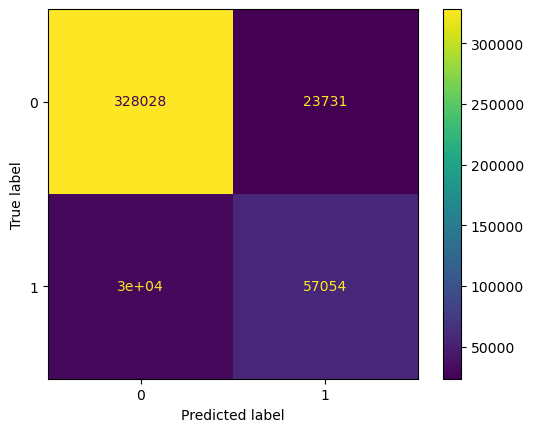

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm)
disp.plot()
plt.show()

In [37]:
lgbm_cm = confusion_matrix(lgbm_df['y'], (lgbm_df['oof'] > 0.5).astype(int))

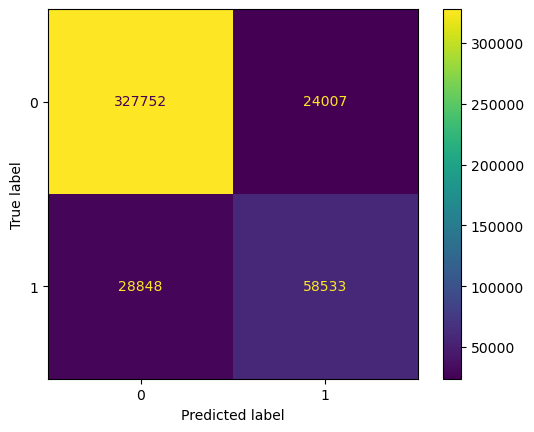

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=lgbm_cm)
disp.plot()
plt.show()

In [43]:
xgb_cm - lgbm_cm

array([[  276,  -276],
       [ 1479, -1479]])

In [44]:
errors = train_df.assign(oof=xgb_df['oof'], err=np.abs(xgb_df['y'] - xgb_df['oof'])).sort_values('err', ascending=False)

In [45]:
errors.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,oof,err
380297,380297,D287,SOFT,Bahrain Grand Prix,2023,0,51,4,11.0,15,98.634,0.030,-24.756,0.894737,0.0,1.0,0.000124,0.999876
267544,267544,D307,SOFT,Bahrain Grand Prix,2023,0,51,4,14.0,1,95.942,-0.309,-20.818,0.894737,0.0,1.0,0.000196,0.999804
93003,93003,D168,HARD,Mexico City Grand Prix,2023,0,33,4,8.0,2,82.100,0.000,0.000,0.464789,0.0,1.0,0.000238,0.999762
302312,302312,PET,MEDIUM,Abu Dhabi Grand Prix,2023,0,13,1,13.0,19,90.923,-0.081,-1.532,0.224138,0.0,1.0,0.000378,0.999622
164253,164253,D236,HARD,Abu Dhabi Grand Prix,2023,0,57,2,31.0,12,90.076,0.088,-20.091,0.982759,0.0,1.0,0.000384,0.999616


In [46]:
errors.groupby('Year')['err'].agg(['mean', 'count'])

,mean,count
Year,,
2022,0.232046,82989
2023,0.017245,136147
2024,0.223033,127110
2025,0.215550,92894


In [47]:
errors.groupby('Compound')['err'].agg(['mean', 'count'])

,mean,count
Compound,,
HARD,0.223720,170518
INTERMEDIATE,0.172707,17382
MEDIUM,0.103910,211141
SOFT,0.173957,38744
WET,0.109409,1355
